In [4]:
### imports...
import numpy as np
import matplotlib.pyplot as plt
import statistics

In [3]:
### basic work for paper tables wrt dataset size
layer_res = [30, 30, 30, 30, 30, 30, 30, 30, 800, 800, 800, 800, 800, 800, 1000, 70, 70, 1000]
pyr_x = np.array([34, 34, 34, 34, 34, 34, 34, 34, 2, 2, 2, 2, 2, 2, 1, 15, 15, 1])
cube_x = np.array([34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 34, 15, 15, 1])
old_adj_x = np.array([24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 24, 15, 15, 1])
adj_x = np.array([25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 25, 15, 15, 1])
y_sum = np.sum(np.array([15, 15, 1]) ** 2)

In [4]:
params_pyr = np.sum(pyr_x ** 2)
params_cube = np.sum(cube_x ** 2)
params_adj = np.sum(adj_x ** 2)
params_old = np.sum(old_adj_x ** 2)

In [5]:
print(params_pyr)
print(params_cube)
print(params_adj)
print("***")
print(params_pyr - y_sum)
print(params_cube - y_sum)
print(params_adj - y_sum)
print("***")
print(1 - (params_pyr/params_cube))

9724
17791
9826
***
9273
17340
9375
***
0.4534315103142038


In [6]:
### overhead and storage cost graph
gb_pyr = 3.86
gb_cube = 7.06
gb_adj = (params_adj / params_old) * 3.61

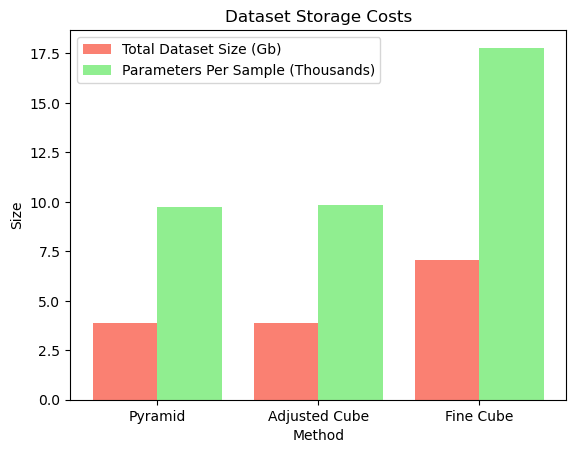

In [7]:
names = ["Pyramid", "Adjusted Cube", "Fine Cube"]
index = np.array([1, 2, 3])
fig, ax = plt.subplots()
disk = ax.bar(index-0.5, [gb_pyr, gb_adj, gb_cube], 0.4, color="salmon")
disk = ax.bar(index-0.1, [params_pyr/1000, params_adj/1000, params_cube/1000], 0.4, color="lightgreen")

ax.set_xticks(index-0.3, names)
ax.set_title("Dataset Storage Costs")
ax.legend(loc='upper left', labels=["Total Dataset Size (Gb)", "Parameters Per Sample (Thousands)"])
ax.set_ylabel('Size')
ax.set_xlabel('Method')

plt.savefig("data_cost_figs/storage_cost.png")

In [8]:
### work on graph for overhead time cost

In [1]:
### ok -- now compile results for model performance table...
import pickle

models_locs = [["../models/trained/f2_singletask_0", "model_f2_singletask_0"],
               ["../models/trained/f2_singletask_1", "model_f2_singletask_1"],
               ["../models/trained/f2_singletask_2", "model_f2_singletask_2"]]

"""models_locs = [["../models/trained/c2_late_a_pyramid", "model_cascade_late_a_pyramid_16x3"],
               ["../models/trained/c2_mid_pyramid", "model_cascade_mid_pyramid_16x3"],
               ["../models/trained/c2_early_b_pyramid", "model_cascade_mid_pyramid_16x3"],
               ["../models/trained/c2_late_a_cube", "model_cascade_late_a_cube_16x3"],
               ["../models/trained/c2_late_a_adjust", "model_cascade_late_a_adjust_16x3"],
               ["../models/trained/multi_vit_pyramid", "model_multiscale_vit_pyramid_16x3"],
               ["../models/trained/multi_vit_cube", "model_multiscale_vit_cube_16x3"],
               ["../models/trained/multi_vit_adjust", "model_multiscale_vit_adjust_16x3"]]"""
###models_locs = [["../models/trained/c2_early_b_pyramid", "model_cascade_early_b_pyramid_16x3_0"],
###               ["../models/trained/c2_mid_cube", "model_cascade_mid_cube_16x3_0"]]
"""               ["../models/trained/c2_early_cube", "cascade_early_cube_8x3"],
               ["../models/trained/c2_early_adjust", "ccascade_early_adjust_8x3"],
               ["../models/trained/c2_mid_pyramid", "cascade_mid_pyramid_8x3"],
               ["../models/trained/c2_mid_cube", "cascade_mid_cube_8x3"],
               ["../models/trained/c2_mid_adjust", "cascade_mid_adjust_8x3"],
               ["../models/trained/c2_late_a_pyramid", "cascade_late_a_pyramid_8x3"],
               ["../models/trained/c2_late_a_cube", "cascade_late_a_cube_8x3"],
               ["../models/trained/c2_late_a_adjust", "cascade_late_a_adjust_8x3"],
               ["../models/trained/multi_vit_pyramid", "multiscale_vit_pyramid_8x3"],
               ["../models/trained/multi_vit_cube", "multiscale_vit_cube_8x3"],
               ["../models/trained/multi_vit_adjust", "multiscale_vit_adjust_8x3"]]"""


on_folds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [2]:
### load metrics pickles
models_metrics = []
for i in range(len(models_locs)):
    print(models_locs[i][0] + "/metrics.txt")
    with open(models_locs[i][0] + "/metrics.txt", "rb") as metrics_log:
        models_metrics.append(pickle.load(metrics_log))

../models/trained/f2_singletask_0/metrics.txt
../models/trained/f2_singletask_1/metrics.txt
../models/trained/f2_singletask_2/metrics.txt


In [5]:
### organization: [metric_type, ylayer, fold]
y_layer_names = ["wue", "esi", "agb"]
print(models_metrics[0]["train"]["time"])
for i in range(len(models_metrics)):
    print(models_locs[i][0])
    for j in range(3):
        foldmse = []
        fold_r2 = []
        for k in range(len(on_folds)):
            foldmse.append(np.mean(models_metrics[i]["val"]["mse_single"][j][k]))
            fold_r2.append(np.mean(models_metrics[i]["val"]["r2"][j][k]))
            print("    ", foldmse[k])
        print(" -", y_layer_names[j] + "_mse mean", np.mean(foldmse), 
              "   std", np.std(foldmse), "  ", y_layer_names[j] + "_r2 mean", np.mean(fold_r2), "   std", np.std(fold_r2), "(" + str(len(foldmse)) + " samples)")
    print(models_locs[i][0], "--", "time mean", np.mean(models_metrics[i]["train"]["time"]), "   std",
          np.std(models_metrics[i]["train"]["time"]))
    print("**")

[33135.422529, 33165.546179000004, 33045.92695800001, 32910.95851900001, 32969.70345600002, 32832.71901900001, 32837.767096999974, 33087.26839100002, 32903.07949099998, 32797.69662600005]
../models/trained/f2_singletask_0
     0.0047547053580995376
     0.0018498022022246277
     0.0018223728898799528
     0.0018286056266252869
     0.001838834811463463
     0.0019193272221265615
     0.003763196989836567
     0.0018304287485648562
     0.0018379273589151316
     0.0031248130978467977
 - wue_mse mean 0.002457001430558278    std 0.0010022453656661943    wue_r2 mean 0.0003962573920612827    std 0.0010180074294343477 (10 samples)
     1032030.9454111888
     148354.60455581456
     15488.670918544422
     6761.451741748845
     0.3716580559538249
     293244.1978013762
     66513.97170743984
     0.28477963503006004
     18.74409538876746
     231855.46005889477
 - esi_mse mean 179426.8702728087    std 301598.37235368206    esi_r2 mean 0.007373961300020404    std 0.03176925009439001 (10 s

In [6]:
33107.593075599994 +33477.345498999995 + 32968.6088265

99553.54740109999

In [11]:
### load data and do distribution graph ... imports
sys.path.append("..")
from models.data_handler import data_wrangler



2024-09-26 15:42:24.005937: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [21]:
### load wrangler
metadata_cols = []
with open("../data/ml_sets/pyramid_lf22/" + "info.txt", 'r') as infofile:
    metadata_total = infofile.read().replace('\n', ';')
metadata_lines = metadata_total.split(";")
metadata = []
for metal in metadata_lines:
    if len(metal) > 0:
        metadata.append(metal.split(","))

other_info = metadata.pop(0)
other_info = {"n_folds": other_info[0], "buffer_nodata": other_info[1], "base_crs": other_info[2],
                }
n_layers = len(metadata)
layer_info = {"layer_dims": [], "x_layers": [], "y_layers": [], "layer_names": []}

for j in range(n_layers):
    layer_info["layer_dims"].append(int(metadata[j][0]))
    layer_info["layer_names"].append(metadata[j][3])
    if metadata[j][1] == "x":
        layer_info["x_layers"].append(j)
    else:
        layer_info["y_layers"].append(j)

print("metadata check")

wrangler = data_wrangler("../data/ml_sets/pyramid_lf22/", 18, 1, layer_info["layer_dims"],
                                   1000, other_info["buffer_nodata"], layer_info["x_layers"],
                                   layer_info["y_layers"], low_mem=False)

y_names = [["Water Use Efficiency", "wue"],
           ["Evaporative Stress Index", "esi"],
           ["Above Ground Biomass", "agb"]]
colors = ["salmon", "lightgreen", "lightblue"]
distkey = ["WUE", "ESI", "AGB"]

metadata check


/var/folders/kq/5tk5wpns4_lc_q8b14gl0m2h0000gn/T/ipykernel_23701/178984871.py:23: RuntimeWarning: divide by zero encountered in log10
  ax.plot(np.arange(nbins)/(nbins/2), np.log10(ys[i]), color=colors[i], label=distkey[i])


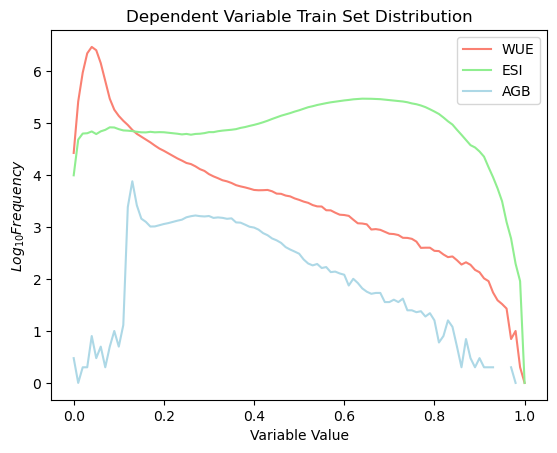

In [14]:
nbins = 200

### dist over train
wrangler.set_mode("train")
ys = [[] for iii in range(3)]

for i in range(len(wrangler)):
    ### val y at batch i
    ys_i = wrangler[i][1]
    for j in range(3):
        for elty in ys_i[j]:
            ys[j].append(elty)
"""
for i in range(3):
    ys[i] = np.arange(500 * (i + 1))/(250 * (i + 1)) """



fig, ax = plt.subplots()

for i in range(3):
    ys[i], b = np.histogram(ys[i], nbins, range=[0, 2])
    ax.plot(np.arange(nbins)/(nbins/2), np.log10(ys[i]), color=colors[i], label=distkey[i])
ax.set(xlabel='Variable Value', ylabel='$Log_{10} Frequency$', title='Dependent Variable Train Set Distribution')
ax.legend(loc="upper right")

/var/folders/kq/5tk5wpns4_lc_q8b14gl0m2h0000gn/T/ipykernel_23701/2329498804.py:20: RuntimeWarning: divide by zero encountered in log10
  ax.plot(np.arange(nbins)/(nbins), np.log10(ys[i]), color=colors[i], label=distkey[i])


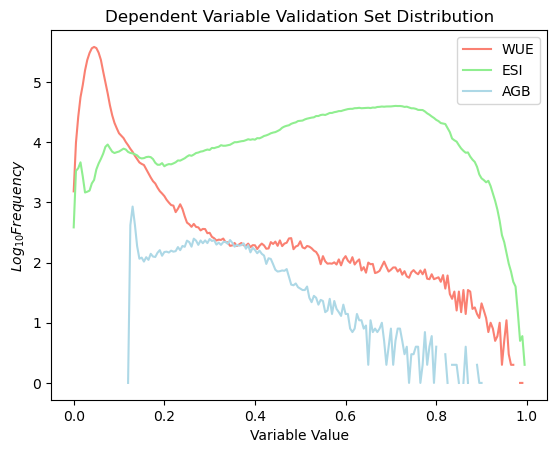

In [15]:
wrangler.set_mode("val")
ys = [[] for iii in range(3)]

for i in range(len(wrangler)):
    ### val y at batch i
    ys_i = wrangler[i][1]
    for j in range(3):
        for elty in ys_i[j]:
            ys[j].append(elty)
"""
for i in range(3):
    ys[i] = np.arange(500 * (i + 1))/(250 * (i + 1)) """



fig, ax = plt.subplots()

for i in range(3):
    ys[i], b = np.histogram(ys[i], nbins, range=[0, 1])
    ax.plot(np.arange(nbins)/(nbins), np.log10(ys[i]), color=colors[i], label=distkey[i])
ax.set(xlabel='Variable Value', ylabel='$Log_{10} Frequency$', title='Dependent Variable Validation Set Distribution')
ax.legend(loc="upper right")

/var/folders/kq/5tk5wpns4_lc_q8b14gl0m2h0000gn/T/ipykernel_23701/2771200118.py:20: RuntimeWarning: divide by zero encountered in log10
  ax.plot(np.arange(nbins)/(nbins/2), np.log10(ys[i]), color=colors[i], label=distkey[i])


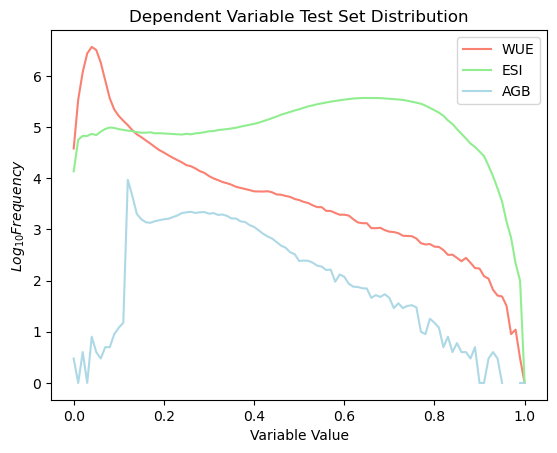

In [16]:
wrangler.set_mode("test")
ys = [[] for iii in range(3)]

for i in range(len(wrangler)):
    ### val y at batch i
    ys_i = wrangler[i][1]
    for j in range(3):
        for elty in ys_i[j]:
            ys[j].append(elty)
"""
for i in range(3):
    ys[i] = np.arange(500 * (i + 1))/(250 * (i + 1)) """



fig, ax = plt.subplots()

for i in range(3):
    ys[i], b = np.histogram(ys[i], nbins, range=[0, 2])
    ax.plot(np.arange(nbins)/(nbins/2), np.log10(ys[i]), color=colors[i], label=distkey[i])
ax.set(xlabel='Variable Value', ylabel='$Log_{10} Frequency$', title='Dependent Variable Test Set Distribution')
ax.legend(loc="upper right")

In [17]:
"""xs = []
print(xs)"""
print(ys[0].shape)

(200,)


In [18]:
nbins = 200

### dist over train
wrangler.set_mode("train")
xs = [[] for ii in range(14)]

for i in range(len(wrangler)):
    ### val y at batch i
    xs_i = wrangler[i][0]
    for j in range(14):
        #print(xs_i)
        for eltx in xs_i[j]:
            xs[j].append(eltx)

In [19]:
for i in range(len(xs)):
    xs[i] = np.array(xs[i])

0.0 1.0 1.0


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


0.0 1.0 1.0


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


0.0 1.0 1.0


...

0.0 1.0 1.0


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


0.0 1.0 1.0


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that 

0.0 1.0 1.0
0.0 1.0 1.0
0.0 1.0 1.0
0.0 1.0 1.0
0.0 1.0 1.0
0.0 1.0 1.0


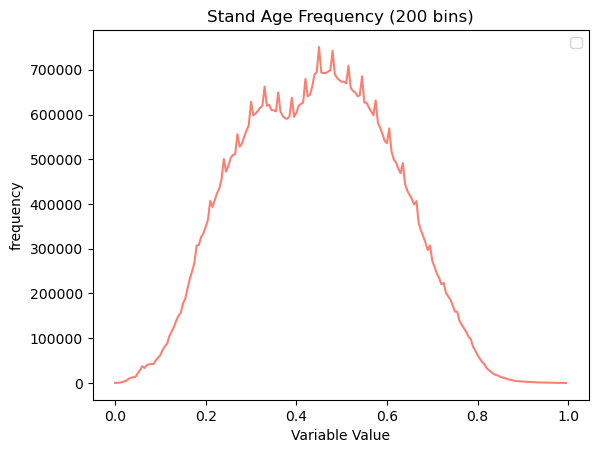

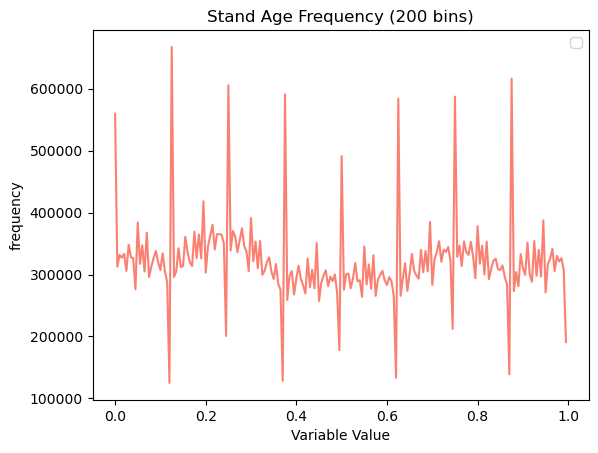

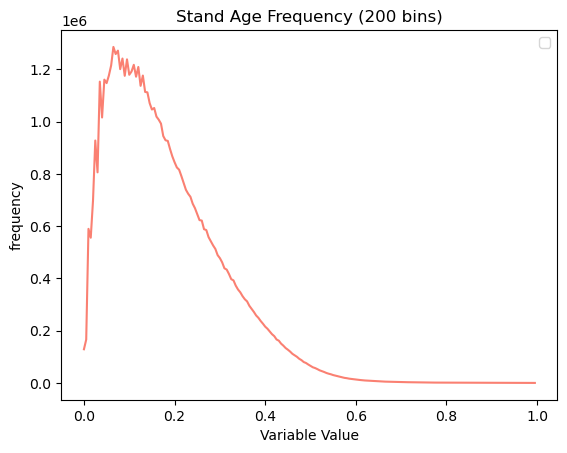

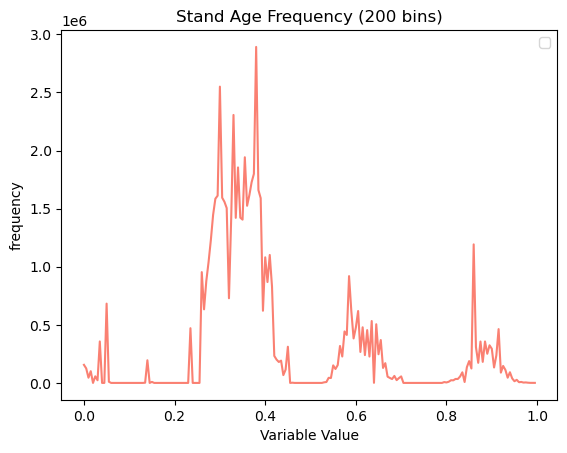

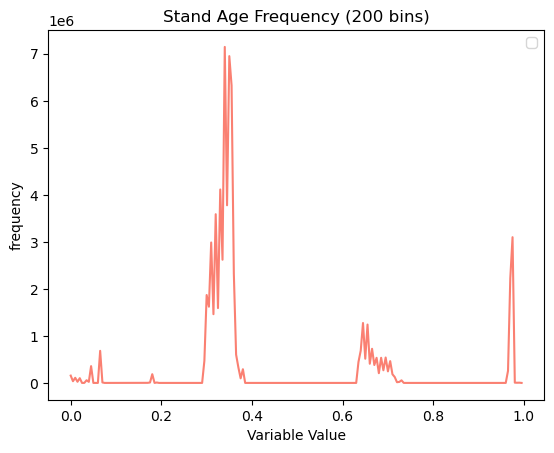

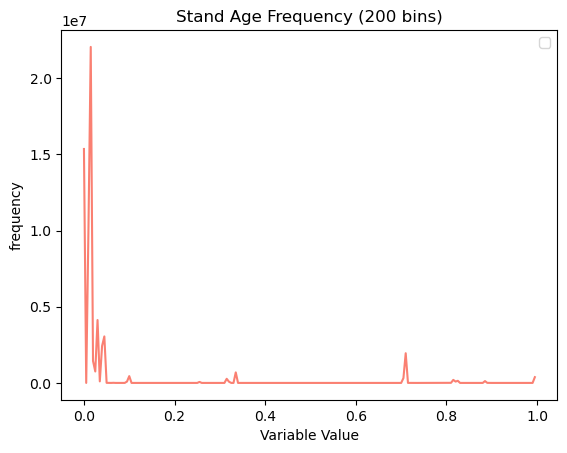

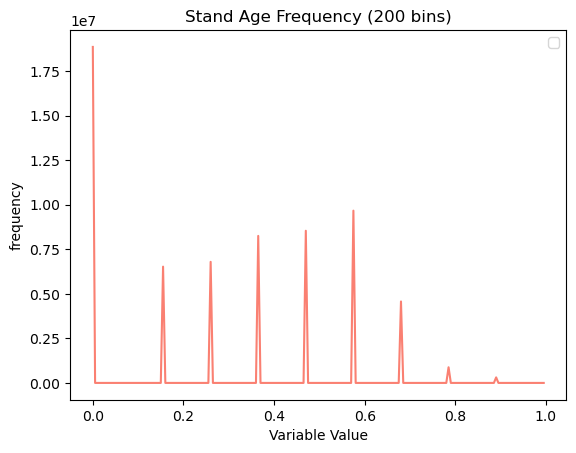

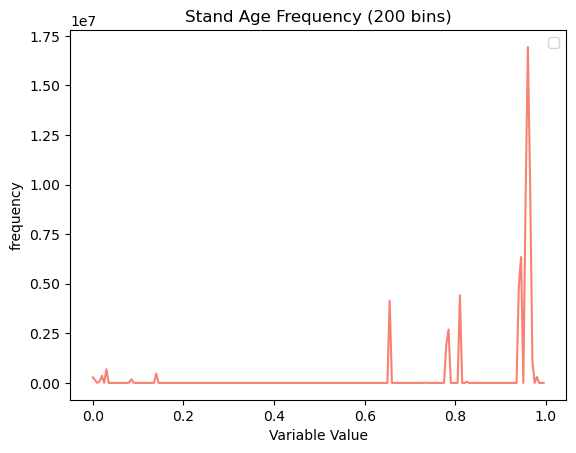

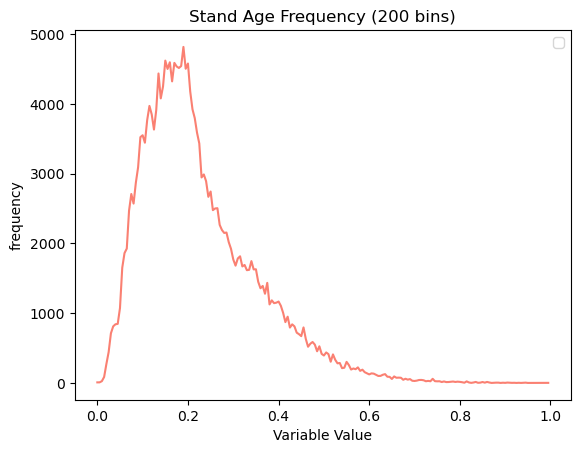

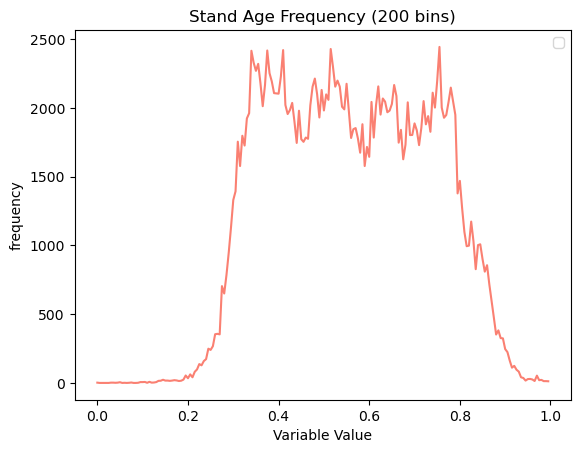

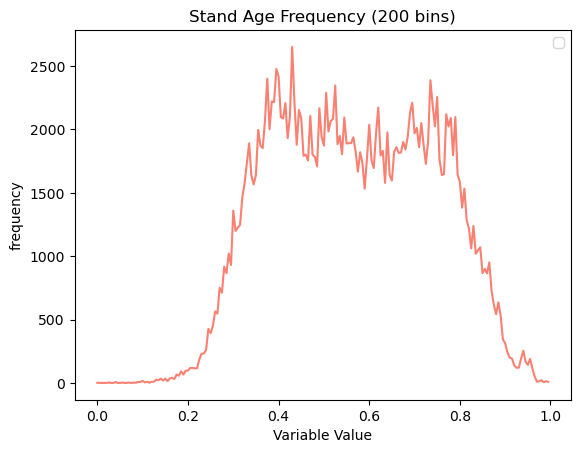

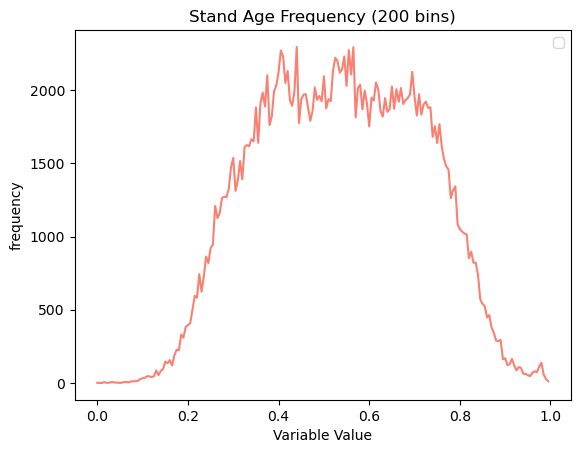

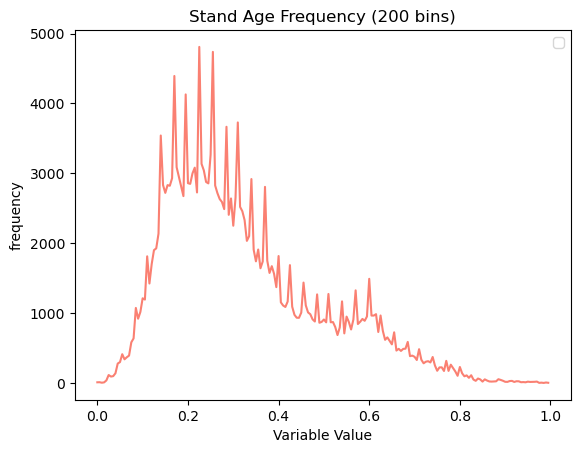

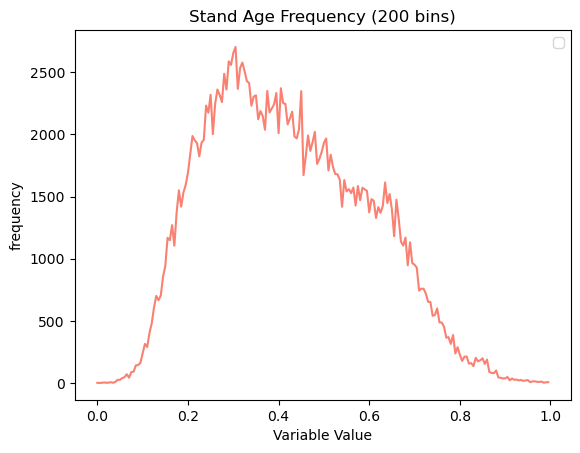

In [20]:

for i in range(len(xs)):
    fig, ax = plt.subplots()

    minvalx = np.min(xs[i])
    maxvalx = np.max(xs[i])
    rangex = maxvalx - minvalx
    print(minvalx, maxvalx, rangex)
    xsi_hist, b = np.histogram(xs[i], nbins, range=[np.min(xs[i]), np.max(xs[i])])
    ax.plot(np.arange(nbins)/(nbins/1), xsi_hist, color=colors[0], )
    ax.set(xlabel='Variable Value', ylabel='frequency', title='Stand Age Frequency (200 bins)')
    ax.legend(loc="upper right")

In [23]:

xsp = [[] for iii in range(3)]
partition = ["train", "val", "test"]
for i in range(len(partition)):
    wrangler.set_mode(partition[i])
    for j in range(len(wrangler)):
        ### val y at batch i
        xsp_j = wrangler[j][0]
        for eltx in xsp_j[-1]:
            xsp[i].append(eltx)


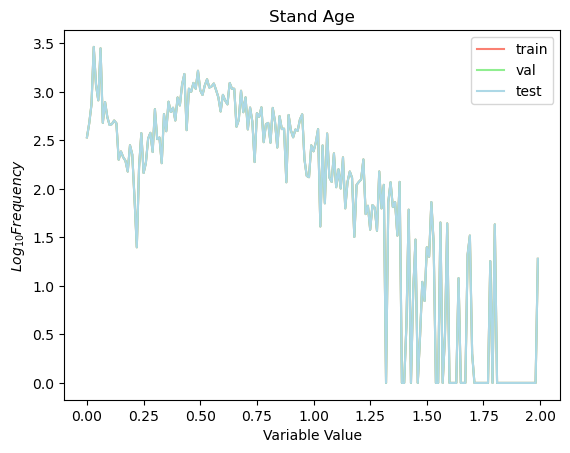

In [25]:
fig, ax = plt.subplots()
nbins = 200
for i in range(3):
    xsp_hi, b = np.histogram(xsp[i], nbins, range=[0, 1])
    ax.plot(np.arange(nbins)/(nbins/2), np.log10(xsp_hi + 1), color=colors[i], label=partition[i])
ax.set(xlabel='Variable Value', ylabel='$Log_{10} Frequency$', title='Stand Age')
ax.legend(loc="upper right")

plt.show()

In [45]:
import h5py

In [48]:
layer_loc =  "../data/ml_sets/pyramid_lf22/layer_14.h5"
h5src = h5py.File(layer_loc,'r')
h5data = h5src["data"]


In [52]:
nph5 = np.array(h5data)
print(len(np.unique(nph5)))

341


In [18]:
from osgeo import gdal
import json
import sys
sys.path.append("../models")
import modelbase.mltools as mlt
import models_main as ml
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [2]:
def read_config(in_loc):
    config_in = open(in_loc)
    config_dict = json.load(config_in)
    return config_dict

loading model from ../models/configs/c2_late_a_pyramid.json
metadata check
['34', 'x', '0', 'SRTM']
['34', 'x', '1', 'Aspect']
['34', 'x', '2', 'Slope']
['34', 'x', '3', 'EVC2022']
['34', 'x', '4', 'EVH2022']
['34', 'x', '5', 'EVT2022']
['34', 'x', '6', 'CC2022']
['34', 'x', '7', 'FVH2022']
['2', 'x', '8', 'Precip']
['2', 'x', '9', 'TempMIN']
['2', 'x', '10', 'TempMEAN']
['2', 'x', '11', 'TempMAX']
['2', 'x', '12', 'VaporMIN']
['2', 'x', '13', 'VaporMAX']
['1', 'x', '14', 'StandAge']
['15', 'y', '15', 'ECOSTRESSWUE']
['15', 'y', '16', 'ECOSTRESSESI']
['1', 'y', '17', 'GEDIAGB']
VALIDATING
building cascade2_late_a model
[1, 2, 34]
[1, 6, 8]
convolutional dims... [1, 2, 2]
finished setting up


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_165     │ (None, 34, 34, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_166     │ (None, 34, 34, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_167     │ (None, 34, 34, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_168     │ (None, 34, 34, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_169     │ (None, 34, 34, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_170     │ (None, 34, 34, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_171     │ (None, 34, 34, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_172     │ (None, 34, 34, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_68      │ (None, 34, 34, 8) │          0 │ input_layer_165[… │
│ (Concatenate)       │                   │            │ input_layer_166[… │
│                     │                   │            │ input_layer_167[… │
│                     │                   │            │ input_layer_168[… │
│                     │                   │            │ input_layer_169[… │
│                     │                   │            │ input_layer_170[… │
│                     │                   │            │ input_layer_171[… │
│                     │                   │            │ input_layer_172[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_79 (Conv2D)  │ (None, 32, 32,    │      4,672 │ concatenate_68[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        256 │ conv2d_79[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_173     │ (None, 2, 2, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_174     │ (None, 2, 2, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_175     │ (None, 2, 2, 1)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_176     │ (None, 2, 2, 1)   │          0 │ -               

 Total params: 7,842,285 (29.92 MB)

 Trainable params: 7,842,045 (29.92 MB)

...

None
done setting up


/Users/jega7451/anaconda3/envs/firerx/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:576: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 90 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


shape sanity check 0 - (13800, 225) (13800, 225)
shape sanity check 1 - (13800, 225) (13800, 225)
shape sanity check 2 - (13800, 1) (13800, 1)
mse dimensions check [(13800,)]
mse dimensions check [(13800,), (13800,)]
mse dimensions check [(13800,), (13800,), (13800,)]
mse dimensions check [(13800,)]
mse dimensions check [(13800,), (13800,)]
mse dimensions check [(13800,), (13800,), (13800,)]


/Users/jega7451/work/firerx_ml/visualize/../models/modelbase/mltools.py:330: RuntimeWarning: divide by zero encountered in log10
  histo_i = np.log10(histo_i)


reformatting metrics...


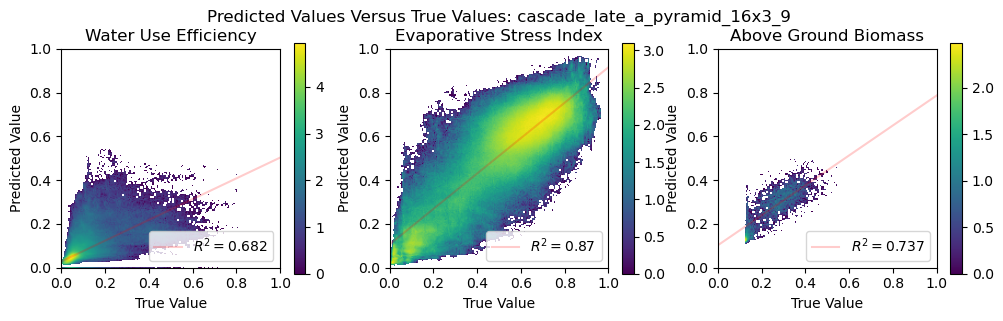

In [ ]:

### idea ... load data, plot predictions geographic predictions, etc. 
### plot error over lat, lon? or rather pixels from left, pixels from top....
### adapt reconstruction from 
### idea is to set up model...
which_model = "c2_late_a_pyramid"

### where is model config; we want to validate on the specified folds models
model_config_loc = "../models/configs/" + which_model + ".json"
actions = ["val"]
print("loading model from", model_config_loc)
### load model params from config file
model_config = read_config(model_config_loc)
### extract run params... we don't need those here...
run_params = model_config["run_params"]
### fix the model dir so we can load from outside the same base directory
run_params["model_dir"] = "../models/" + run_params["model_dir"]
### fix this to the specific fold we want to analyze, if only one...
run_params["train_params"]["run_on_folds"] = [9]
### model params... we do need those here...
model_parameters = model_config["model_params"]

### we need to load model and then validate it... "val" action does this, won't rewrite model.
metadata = mlt.load_metadata(run_params["data_root_dir"])
ml.setup_train_model(actions, run_params, model_parameters, metadata)



loading model metrics from ../models/trained/c2_late_a_pyramid/metrics.txt
     n samples in fold 9 (13800,)
     n samples in fold 9 (13800,)
     n samples in fold 9 (13800,)
n total samples in dataset (98809, 2)
sanity check: n samples in loaded vali fold indices 13800
(13800,)


[Text(0.5, 1.0, 'Model Error Versus Latitude'),
 Text(0.5, 0, 'Scaled Vertical Offset from Southernmost Sample')]

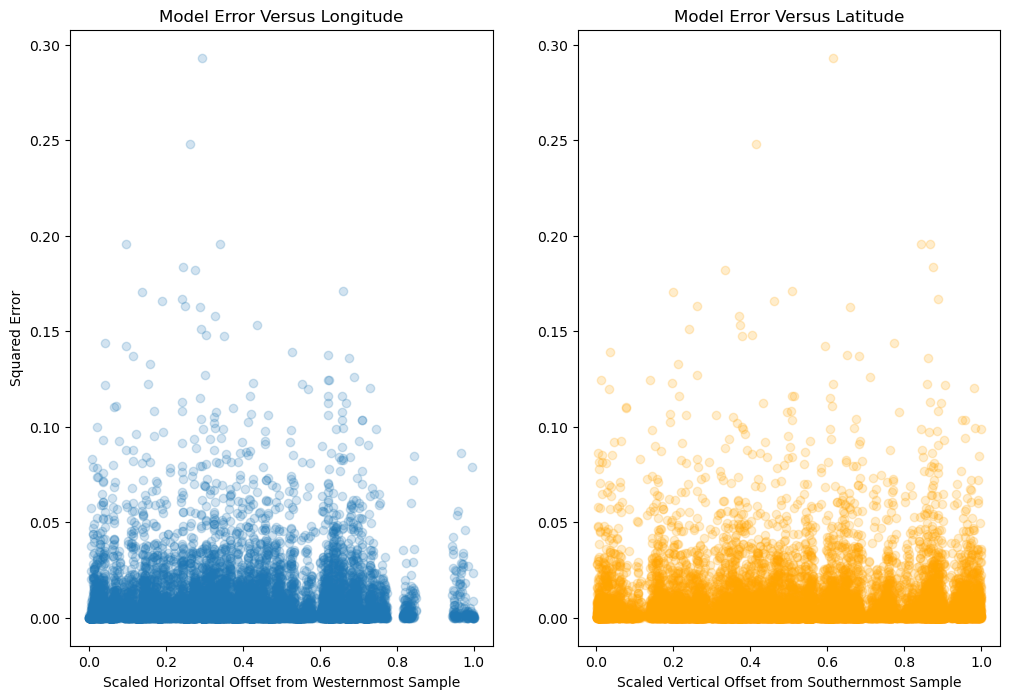

In [41]:
### alternatively, load metric file...
which_model = "c2_late_a_pyramid"
data_type = "pyramid"

### where is model metrics log???
model_metrics_loc = "../models/trained/" + which_model + "/metrics.txt"
print("loading model metrics from", model_metrics_loc)

### load metric pickle -- specific file
specific_metric = None
with open(model_metrics_loc, "rb") as mlog:
    specific_metric = pickle.load(mlog)

### organization: [metric_type, ylayer, fold]
y_layer_names = ["wue", "esi", "agb"]
specific_folds = [9]
#print(models_metrics["train"]["time"])
for j in range(3):
    specific_foldmse = []
    specific_fold_r2 = []
    for k in range(len(specific_folds)):
        specific_foldmse.append(specific_metric["val"]["mse_single"][j][k])
        specific_fold_r2.append(specific_metric["val"]["r2"][j][k])
        print("     n samples in fold", specific_folds[k], specific_foldmse[k].shape)

### need to invert from legal ids to location. First, load legal sample ids, which is list of indices
loaded_legal_ids = np.genfromtxt("../data/ml_sets/" + data_type + "_v10/legal_ids.csv", delimiter=",")
if True:
    loaded_ids = loaded_legal_ids.astype(int)
print("n total samples in dataset", loaded_legal_ids.shape)

### load split sample ids..
specific_split_sample_ids = np.genfromtxt("../data/ml_sets/" + data_type + "_v10/val_" + str(specific_folds[0]) + ".csv", delimiter=',')
print("sanity check: n samples in loaded vali fold indices", len(specific_split_sample_ids))

### invert.
### plot first error vs lon
### plot second error vs lat
### aggregate error over position with lat/lon on x, error on right
print(loaded_legal_ids[specific_split_sample_ids.astype(int)][:,:1].reshape(-1).shape)
#loaded_legal_ids[][:1].reshape(-1)
fix, axs = plt.subplots(1, 2, figsize=(12, 8))
axs[0].scatter(loaded_legal_ids[specific_split_sample_ids.astype(int)][:,0].reshape(-1)/np.max(loaded_legal_ids[specific_split_sample_ids.astype(int)][:,0].reshape(-1)), specific_foldmse[0], alpha=0.2)
axs[0].set(title="Model Error Versus Longitude", xlabel="Scaled Horizontal Offset from Westernmost Sample", ylabel="Squared Error")
axs[1].scatter(loaded_legal_ids[specific_split_sample_ids.astype(int)][:,1].reshape(-1)/np.max(loaded_legal_ids[specific_split_sample_ids.astype(int)][:,1].reshape(-1)), specific_foldmse[0], color='orange', alpha=0.2)
axs[1].set(title="Model Error Versus Latitude", xlabel="Scaled Vertical Offset from Southernmost Sample")

In [53]:
### alternatively -- bin and report mean errors 
n_bins = 100
lli_h = loaded_legal_ids[specific_split_sample_ids.astype(int)][:,0].reshape(-1)
lli_v = loaded_legal_ids[specific_split_sample_ids.astype(int)][:,1].reshape(-1)
max_h = np.max(lli_h)
min_h = np.min(lli_h)

max_v = np.max(lli_v)
min_v = np.min(lli_v)

h_binsum = np.zeros(n_bins)
v_binsum = np.zeros(n_bins)
h_bincount = np.zeros(n_bins)
v_bincount = np.zeros(n_bins)

for i in range(n_bins+1):
    h_bin_lower = i * (max_h - min_h)/n_bins 
    h_bin_upper = (i + 1) * (max_h - min_h)/n_bins
    v_bin_lower = i * (max_v - min_v)/n_bins 
    v_bin_upper = (i + 1) * (max_v - min_v)/n_bins
    h_bin_get = specific_foldmse[0][(lli_h >= h_bin_lower) & (lli_h < h_bin_upper)] 
    v_bin_get = specific_foldmse[0][(lli_v >= v_bin_lower) & (lli_v < v_bin_upper)] 
    h_bincount[min(i, n_bins-1)] += h_bin_get.size
    v_bincount[min(i, n_bins-1)] += v_bin_get.size
    h_binsum[min(i, n_bins-1)] += np.sum(h_bin_get)
    v_binsum[min(i, n_bins-1)] += np.sum(v_bin_get)
binspace = np.arange(n_bins)/100
h_binsum[(h_bincount > 0)] /= h_bincount[(h_bincount > 0)]
v_binsum[(v_bincount > 0)] /= v_bincount[(v_bincount > 0)]

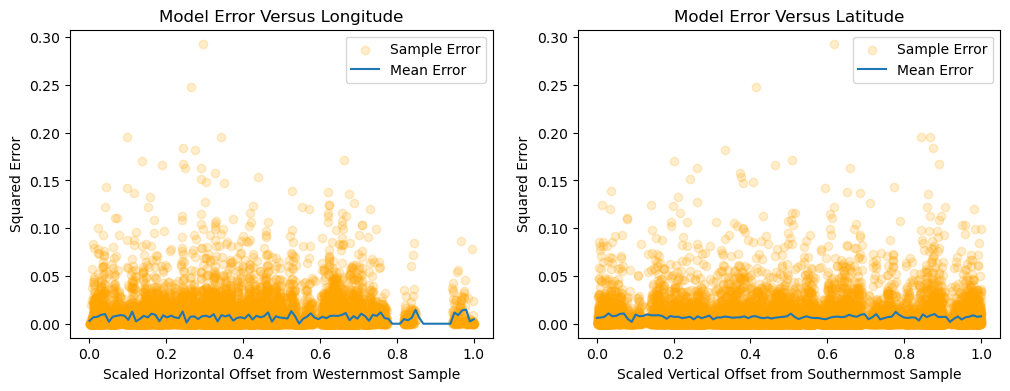

In [62]:
fix, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].scatter(lli_h/max_h, specific_foldmse[0], color="orange", alpha=0.2, label="Sample Error")
axs[0].plot(np.arange(n_bins)/(n_bins-1), h_binsum, label="Mean Error")
axs[0].set(title="Model Error Versus Longitude", xlabel="Scaled Horizontal Offset from Westernmost Sample", ylabel="Squared Error")
axs[0].legend()
axs[1].scatter(lli_v/max_v, specific_foldmse[0], color="orange", alpha=0.2, label="Sample Error")
axs[1].plot(np.arange(n_bins)/(n_bins-1), v_binsum, label="Mean Error")
axs[1].set(title="Model Error Versus Latitude", xlabel="Scaled Vertical Offset from Southernmost Sample", ylabel="Squared Error")
axs[1].legend()